In [1]:
print("RRKK")

RRKK


In [3]:
# Install required libraries (do this once)
!pip install -q tensorflow kaggle


In [4]:
# Interactive upload of kaggle.json
from google.colab import files
uploaded = files.upload()  # click "Choose Files" and upload kaggle.json

if 'kaggle.json' in uploaded:
    print("Uploaded kaggle.json ✅")
else:
    print("No kaggle.json uploaded. If you prefer, paste your Kaggle username & key in the next cell.")


Saving kaggle.json to kaggle.json
Uploaded kaggle.json ✅


In [5]:
# If you don't have file to upload, create kaggle.json by pasting your username and key.
# Replace with your own values (only run this if you didn't upload kaggle.json)
create_from_input = False  # set to True to enable manual input creation

if create_from_input:
    kaggle_username = "YOUR_KAGGLE_USERNAME"
    kaggle_key = "YOUR_KAGGLE_KEY"
    import json, os
    data = {"username": kaggle_username, "key": kaggle_key}
    os.makedirs('/root/.kaggle', exist_ok=True)
    with open('/root/.kaggle/kaggle.json', 'w') as f:
        json.dump(data, f)
    !chmod 600 /root/.kaggle/kaggle.json
    print("Created /root/.kaggle/kaggle.json from pasted credentials.")
else:
    print("Skipped manual creation. Upload via cell 2 if needed.")


Skipped manual creation. Upload via cell 2 if needed.


In [6]:
# STEP 1: Upload kaggle.json file from your computer
from google.colab import files
uploaded = files.upload()  # choose the kaggle.json file you downloaded from Kaggle

if 'kaggle.json' in uploaded:
    print("✅ kaggle.json uploaded successfully!")
else:
    print("⚠️ kaggle.json not found — please re-run and upload it.")


Saving kaggle.json to kaggle (1).json
⚠️ kaggle.json not found — please re-run and upload it.


In [7]:
from google.colab import files
uploaded = files.upload()  # choose your kaggle.json file from Downloads


Saving kaggle.json to kaggle (2).json


In [10]:
%%bash
# STEP 2: Fix the filename and move to correct location

mkdir -p /root/.kaggle

# Rename file if necessary (handles kaggle.json, kaggle (1).json, kaggle (2).json)
if [ -f "kaggle.json" ]; then
  mv kaggle.json /root/.kaggle/kaggle.json
elif [ -f "kaggle (1).json" ]; then
  mv "kaggle (1).json" /root/.kaggle/kaggle.json
elif [ -f "kaggle (2).json" ]; then
  mv "kaggle (2).json" /root/.kaggle/kaggle.json
fi

chmod 600 /root/.kaggle/kaggle.json

# ✅ Verify installation
ls -l /root/.kaggle


total 4
-rw------- 1 root root 69 Oct 22 12:26 kaggle.json


In [11]:
# Download the GuacNN dataset from Kaggle
!kaggle datasets download -d kriisanfarmer/guacnn

# Unzip the dataset
!unzip -q guacnn.zip -d /content/guacnn


Dataset URL: https://www.kaggle.com/datasets/kriisanfarmer/guacnn
License(s): MIT
 63% 150M/239M [00:00<00:00, 1.56GB/s]
100% 239M/239M [00:00<00:00, 1.00GB/s]


In [12]:
!ls /content/guacnn


data


In [13]:
!ls /content/guacnn/data/train


algal_leaf_spot  fruit_healthy	insect_bite  scab    yellow_leaf_disease
black_mold	 healthy_leaf	red_rust     scorch


Found 9000 images belonging to 9 classes.
Found 1125 images belonging to 9 classes.
Found 1125 images belonging to 9 classes.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,840,137 (56.61 MB)

 Trainable params: 14,840,137 (56.61 MB)

...

563/563 ━━━━━━━━━━━━━━━━━━━━ 140s 249ms/step - accuracy: 0.9236 - loss: 0.2478 - val_accuracy: 0.9609 - val_loss: 0.1246
Epoch 32/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9091 - loss: 0.2688
Epoch 32: val_loss did not improve from 0.12464
563/563 ━━━━━━━━━━━━━━━━━━━━ 139s 247ms/step - accuracy: 0.9091 - loss: 0.2688 - val_accuracy: 0.8996 - val_loss: 0.3084
Epoch 33/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.9164 - loss: 0.2606
Epoch 33: val_loss did not improve from 0.12464
563/563 ━━━━━━━━━━━━━━━━━━━━ 139s 247ms/step - accuracy: 0.9164 - loss: 0.2606 - val_accuracy: 0.9467 - val_loss: 0.1422
Epoch 34/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9216 - loss: 0.2425
Epoch 34: val_loss did not improve from 0.12464
563/563 ━━━━━━━━━━━━━━━━━━━━ 139s 247ms/step - accuracy: 0.9216 - loss: 0.2425 - val_accuracy: 0.9493 - val_loss: 0.1315
Epoch 35/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9160 - loss: 0.2556
Epoch 35: val_lo

563/563 ━━━━━━━━━━━━━━━━━━━━ 141s 250ms/step - accuracy: 0.9160 - loss: 0.2556 - val_accuracy: 0.9636 - val_loss: 0.0998
Epoch 36/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9283 - loss: 0.2157
Epoch 36: val_loss did not improve from 0.09982
563/563 ━━━━━━━━━━━━━━━━━━━━ 139s 246ms/step - accuracy: 0.9283 - loss: 0.2157 - val_accuracy: 0.9662 - val_loss: 0.1029
Epoch 37/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.9261 - loss: 0.2237
Epoch 37: val_loss improved from 0.09982 to 0.09504, saving model to /content/best_cnn_model.h5


563/563 ━━━━━━━━━━━━━━━━━━━━ 141s 250ms/step - accuracy: 0.9261 - loss: 0.2236 - val_accuracy: 0.9591 - val_loss: 0.0950
Epoch 38/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9271 - loss: 0.2324
Epoch 38: val_loss did not improve from 0.09504
563/563 ━━━━━━━━━━━━━━━━━━━━ 139s 247ms/step - accuracy: 0.9271 - loss: 0.2324 - val_accuracy: 0.9671 - val_loss: 0.0981
Epoch 39/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9197 - loss: 0.2412
Epoch 39: val_loss did not improve from 0.09504
563/563 ━━━━━━━━━━━━━━━━━━━━ 140s 248ms/step - accuracy: 0.9197 - loss: 0.2412 - val_accuracy: 0.9564 - val_loss: 0.1326
Epoch 40/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.9312 - loss: 0.2171
Epoch 40: val_loss did not improve from 0.09504
563/563 ━━━━━━━━━━━━━━━━━━━━ 138s 244ms/step - accuracy: 0.9312 - loss: 0.2171 - val_accuracy: 0.9582 - val_loss: 0.1209
Epoch 41/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.9393 - loss: 0.2025
Epoch 41: val_lo

563/563 ━━━━━━━━━━━━━━━━━━━━ 141s 250ms/step - accuracy: 0.9393 - loss: 0.2025 - val_accuracy: 0.9724 - val_loss: 0.0832
Epoch 42/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.9256 - loss: 0.2392
Epoch 42: val_loss improved from 0.08323 to 0.07681, saving model to /content/best_cnn_model.h5


563/563 ━━━━━━━━━━━━━━━━━━━━ 142s 252ms/step - accuracy: 0.9256 - loss: 0.2391 - val_accuracy: 0.9707 - val_loss: 0.0768
Epoch 43/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.9361 - loss: 0.1973
Epoch 43: val_loss did not improve from 0.07681
563/563 ━━━━━━━━━━━━━━━━━━━━ 143s 254ms/step - accuracy: 0.9361 - loss: 0.1974 - val_accuracy: 0.9653 - val_loss: 0.1134
Epoch 44/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.9202 - loss: 0.2395
Epoch 44: val_loss did not improve from 0.07681
563/563 ━━━━━━━━━━━━━━━━━━━━ 138s 246ms/step - accuracy: 0.9202 - loss: 0.2394 - val_accuracy: 0.9716 - val_loss: 0.0909
Epoch 45/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.9395 - loss: 0.1896
Epoch 45: val_loss did not improve from 0.07681
563/563 ━━━━━━━━━━━━━━━━━━━━ 141s 250ms/step - accuracy: 0.9395 - loss: 0.1896 - val_accuracy: 0.9556 - val_loss: 0.1113
Epoch 46/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.9372 - loss: 0.2004
Epoch 46: val_lo

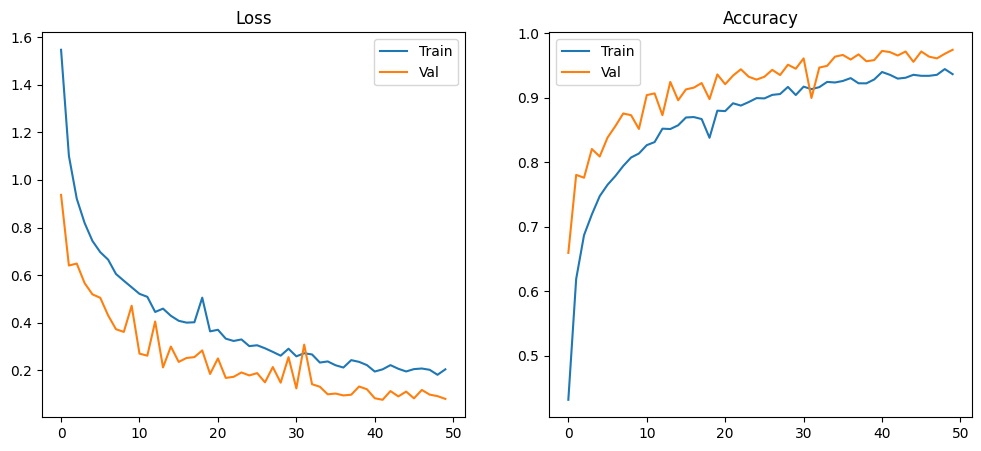

71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9774 - loss: 0.0782


✅ Test Accuracy: 0.9760
✅ Test Loss: 0.0792
💾 Final model saved to: /content/cnn_image_classifier_final.h5


In [14]:
# ===============================
# GuacNN CNN Training - 9 Classes
# Image size: 256x256, Epochs: 50, No EarlyStopping
# ===============================

import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import ModelCheckpoint

# ===============================
# 🔧 Paths - Adjust if needed
# ===============================
base_dir = '/content/guacnn/data'  # root folder containing train/valid/test
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'valid')
test_dir = os.path.join(base_dir, 'test')
save_dir = '/content'
os.makedirs(save_dir, exist_ok=True)

# ===============================
# ⚙️ Parameters
# ===============================
batch_size = 16
img_height, img_width = 256, 256
epochs = 50

# ===============================
# 📦 Data Generators
# ===============================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=(img_height, img_width),
    batch_size=batch_size, class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    validation_dir, target_size=(img_height, img_width),
    batch_size=batch_size, class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    test_dir, target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# ===============================
# 🧠 CNN Model
# ===============================
inp = Input(shape=(img_height, img_width, 3))
x = layers.Conv2D(32, (3,3), activation='relu')(inp)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(128, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(train_gen.num_classes, activation='softmax')(x)

model = models.Model(inputs=inp, outputs=out)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ===============================
# 💾 Model Checkpoint
# ===============================
checkpoint = ModelCheckpoint(
    os.path.join(save_dir, 'best_cnn_model.h5'),
    monitor='val_loss', save_best_only=True, verbose=1
)

# ===============================
# 🚀 Train
# ===============================
history = model.fit(
    train_gen,
    epochs=epochs,
    validation_data=val_gen,
    callbacks=[checkpoint]
)

# ===============================
# 📈 Plot metrics
# ===============================
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(history.history['loss'], label='Train')
ax[0].plot(history.history['val_loss'], label='Val')
ax[0].set_title('Loss'); ax[0].legend()
ax[1].plot(history.history['accuracy'], label='Train')
ax[1].plot(history.history['val_accuracy'], label='Val')
ax[1].set_title('Accuracy'); ax[1].legend()
plt.show()

# ===============================
# 🧪 Evaluate & Save final
# ===============================
test_loss, test_acc = model.evaluate(test_gen)
print(f"✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")

final_model_path = os.path.join(save_dir, 'cnn_image_classifier_final.h5')
model.save(final_model_path)
print(f"💾 Final model saved to: {final_model_path}")


In [15]:
from google.colab import files
import os

# Paths to your models
save_dir = '/content'
best_model_path = os.path.join(save_dir, 'best_cnn_model.h5')
final_model_path = os.path.join(save_dir, 'cnn_image_classifier_final.h5')

# Download best model
files.download(best_model_path)

# Download final model
files.download(final_model_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Best model loaded for testing.
Found 1125 images belonging to 9 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step


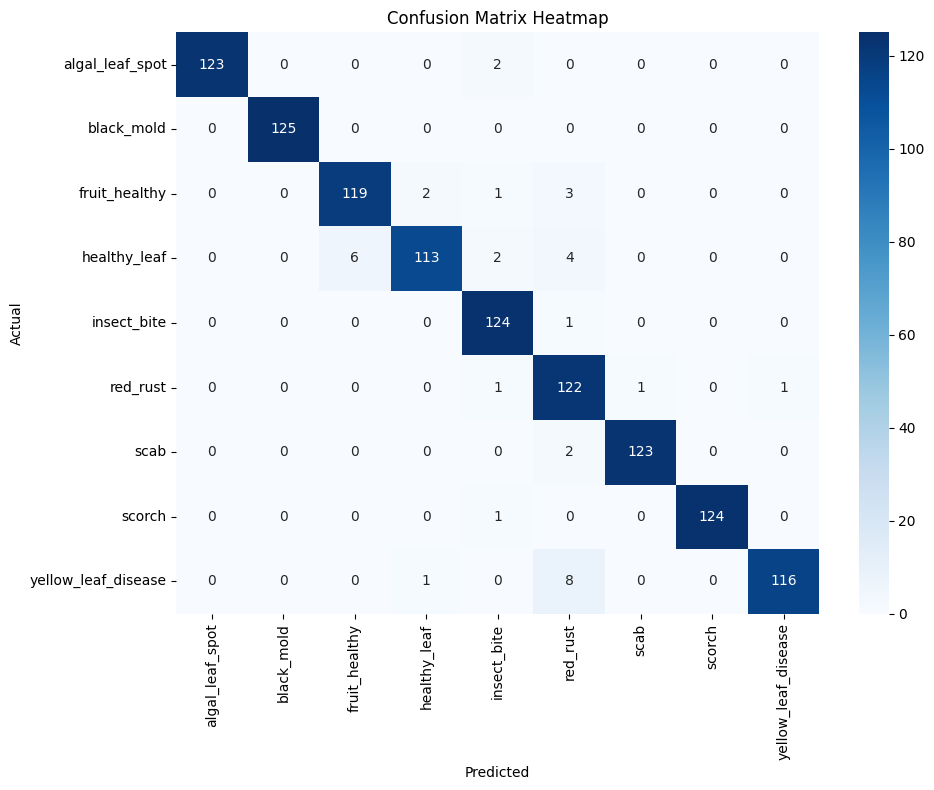

📄 Classification Report:

                     precision    recall  f1-score   support

    algal_leaf_spot       1.00      0.98      0.99       125
         black_mold       1.00      1.00      1.00       125
      fruit_healthy       0.95      0.95      0.95       125
       healthy_leaf       0.97      0.90      0.94       125
        insect_bite       0.95      0.99      0.97       125
           red_rust       0.87      0.98      0.92       125
               scab       0.99      0.98      0.99       125
             scorch       1.00      0.99      1.00       125
yellow_leaf_disease       0.99      0.93      0.96       125

           accuracy                           0.97      1125
          macro avg       0.97      0.97      0.97      1125
       weighted avg       0.97      0.97      0.97      1125



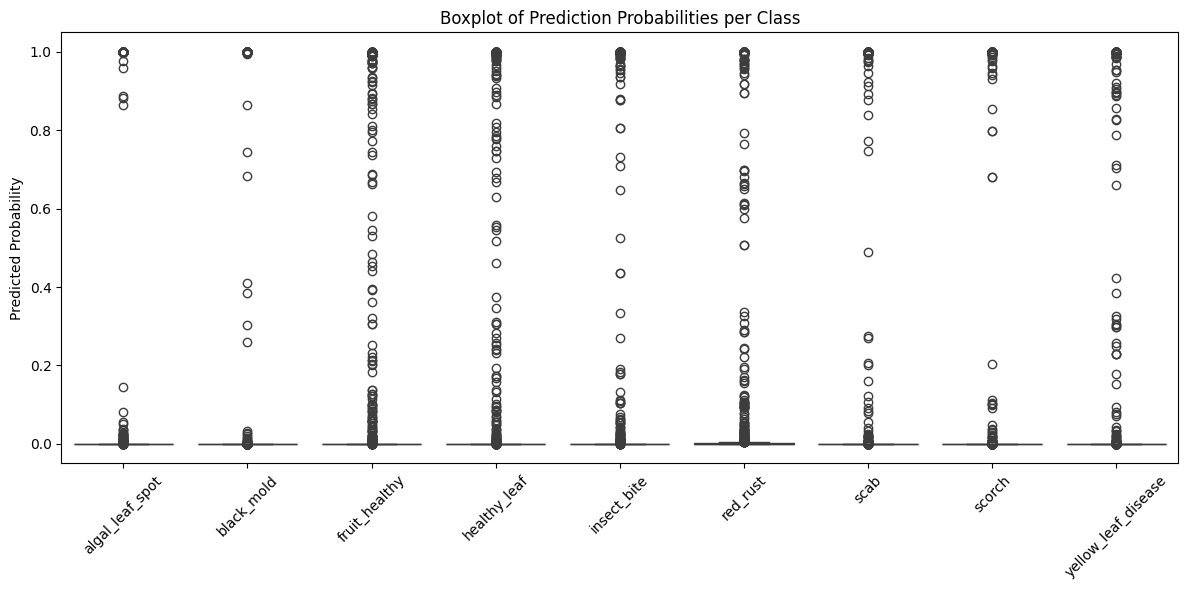

✅ Figures saved: confusion_matrix_heatmap.png, boxplot_pred_probs.png


In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

# ===============================
# Paths
# ===============================
save_dir = '/content'
test_dir = '/content/guacnn/data/test'
best_model_path = os.path.join(save_dir, 'best_cnn_model.h5')

# ===============================
# Load best model
# ===============================
model = load_model(best_model_path)
print("✅ Best model loaded for testing.")

# ===============================
# Test Data Generator
# ===============================
img_height, img_width = 256, 256
batch_size = 16

test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# ===============================
# Predictions
# ===============================
pred_probs = model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# ===============================
# Confusion Matrix & Heatmap
# ===============================
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'confusion_matrix_heatmap.png'))
plt.show()

# ===============================
# Classification Report
# ===============================
report = classification_report(y_true, y_pred, target_names=class_names)
print("📄 Classification Report:\n")
print(report)

# ===============================
# Boxplot of Prediction Probabilities
# ===============================
plt.figure(figsize=(12,6))
sns.boxplot(data=pred_probs, orient='v')
plt.xticks(ticks=np.arange(len(class_names)), labels=class_names, rotation=45)
plt.ylabel("Predicted Probability")
plt.title("Boxplot of Prediction Probabilities per Class")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'boxplot_pred_probs.png'))
plt.show()

print("✅ Figures saved: confusion_matrix_heatmap.png, boxplot_pred_probs.png")


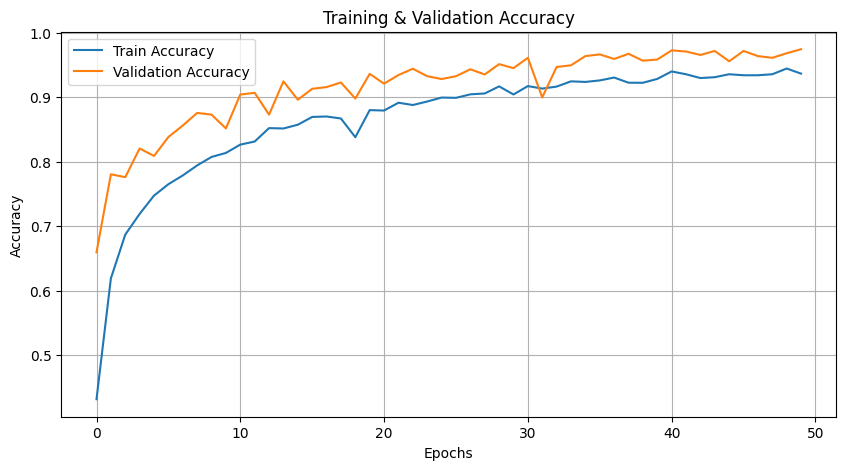

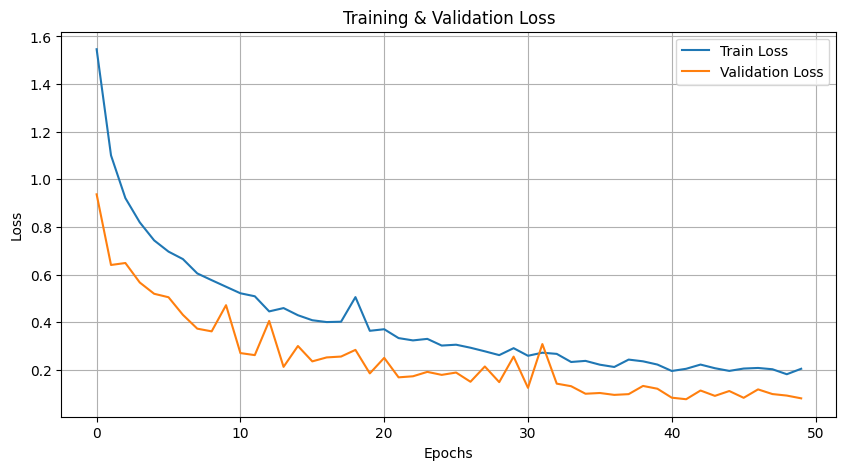

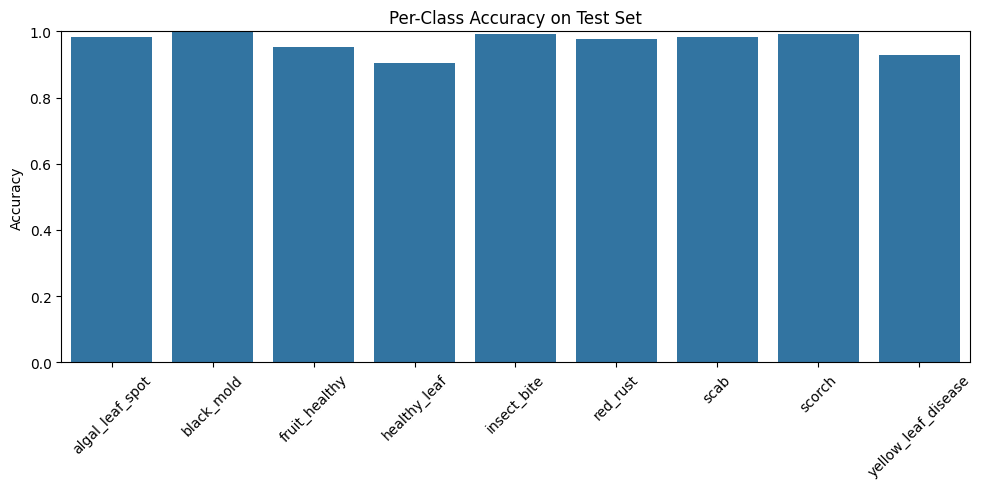

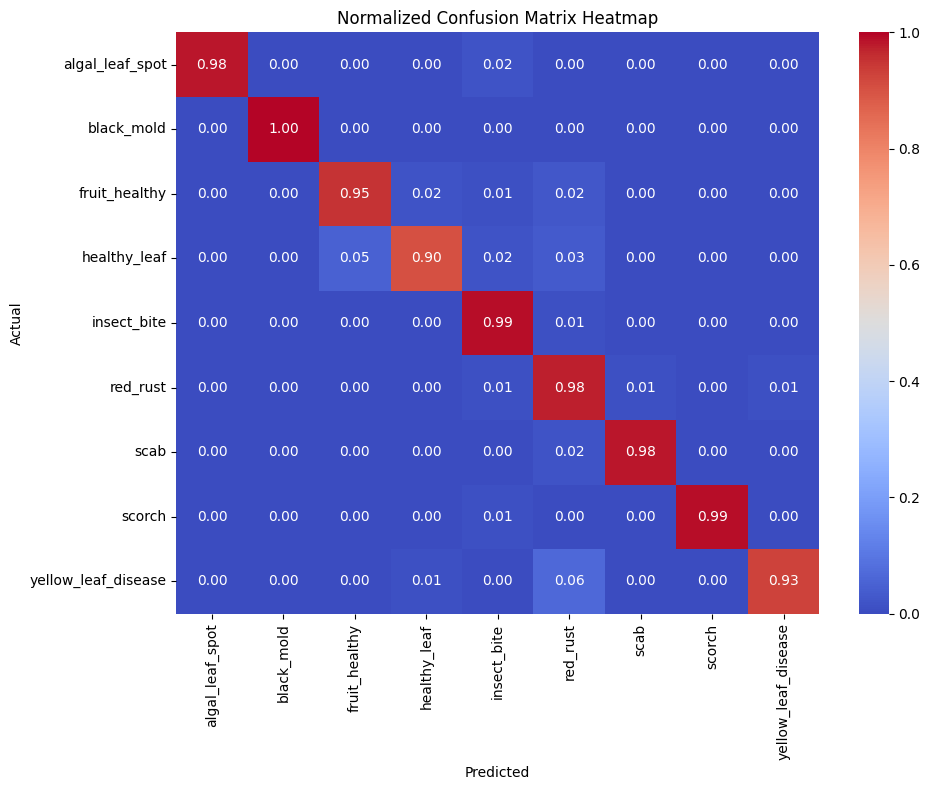

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

# ===============================
# Assume 'history' from training is saved or use placeholder
# If you don't have 'history', you can skip loss/accuracy curves
# ===============================

# Training curves (replace with actual history if available)
# Example: history.history['accuracy'], history.history['val_accuracy']
try:
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    # Accuracy Curve
    plt.figure(figsize=(10,5))
    plt.plot(acc, label='Train Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Training & Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.savefig('/content/accuracy_curve.png')
    plt.show()

    # Loss Curve
    plt.figure(figsize=(10,5))
    plt.plot(loss, label='Train Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig('/content/loss_curve.png')
    plt.show()
except:
    print("⚠️ History not found. Skipping training curves.")

# ===============================
# Per-Class Accuracy Bar Chart
# ===============================
class_acc = np.diag(cm) / np.sum(cm, axis=1)
plt.figure(figsize=(10,5))
sns.barplot(x=class_names, y=class_acc)
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Per-Class Accuracy on Test Set")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/per_class_accuracy.png')
plt.show()

# ===============================
# Normalized Confusion Matrix Heatmap
# ===============================
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10,8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='coolwarm', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Normalized Confusion Matrix Heatmap")
plt.tight_layout()
plt.savefig('/content/normalized_confusion_matrix.png')
plt.show()


In [18]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score

# Paths
best_model_path = '/content/best_cnn_model.h5'
test_dir = '/content/guacnn/data/test'

# Load model
model = load_model(best_model_path)

# Test data generator
img_height, img_width = 256, 256
batch_size = 16

test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Predictions
y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

# Compute accuracy
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"✅ Test Accuracy: {test_accuracy*100:.2f}%")


Found 1125 images belonging to 9 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
✅ Test Accuracy: 96.80%


✅ Final Training Accuracy: 93.64%
✅ Final Validation Accuracy: 97.42%


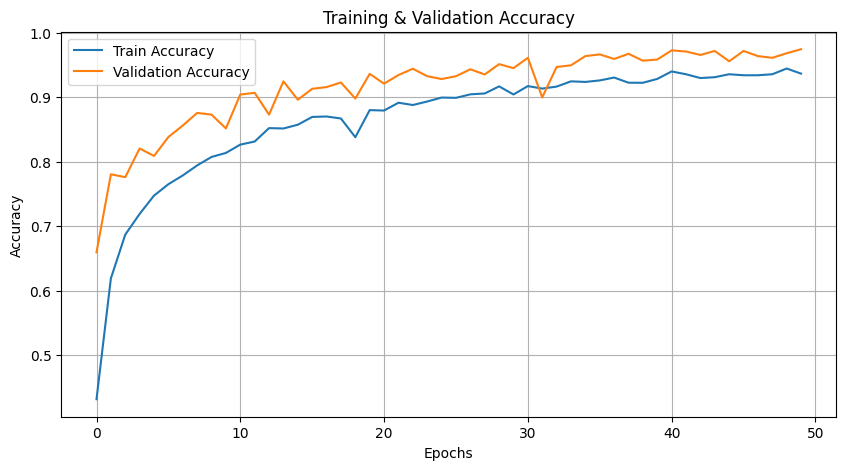

In [19]:
import matplotlib.pyplot as plt

# Assume you still have 'history' from model.fit()
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Print final epoch training & validation accuracy
print(f"✅ Final Training Accuracy: {acc[-1]*100:.2f}%")
print(f"✅ Final Validation Accuracy: {val_acc[-1]*100:.2f}%")

# Optional: plot curves
plt.figure(figsize=(10,5))
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


Saving leaves-jackfruit-tree-close-up-scientific-name-artocarpus-heterophyllus-284973790.webp to leaves-jackfruit-tree-close-up-scientific-name-artocarpus-heterophyllus-284973790.webp
✅ Uploaded Image: leaves-jackfruit-tree-close-up-scientific-name-artocarpus-heterophyllus-284973790.webp


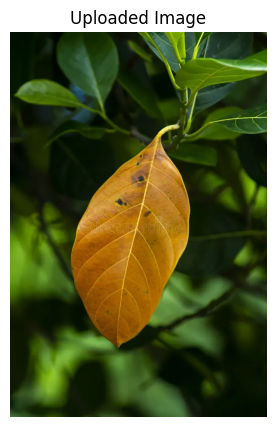

✅ Model Loaded.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
✅ Predicted Class: red_rust
✅ Probability: 82.66%


In [32]:
# ===============================
# Full Image Test + Display + Prediction
# ===============================
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from google.colab import files
import matplotlib.pyplot as plt
from PIL import Image

# -------------------------------
# Step 1: Upload Image
# -------------------------------
uploaded = files.upload()

# Take the first uploaded image
img_filename = list(uploaded.keys())[0]
img_path = f'/content/{img_filename}'
print(f"✅ Uploaded Image: {img_filename}")

# -------------------------------
# Step 2: Display Image
# -------------------------------
img_display = Image.open(img_path)
plt.figure(figsize=(5,5))
plt.imshow(img_display)
plt.axis('off')
plt.title("Uploaded Image")
plt.show()

# -------------------------------
# Step 3: Load Model
# -------------------------------
model_path = '/content/best_cnn_model.h5'  # Replace if different
model = load_model(model_path)
print("✅ Model Loaded.")

# -------------------------------
# Step 4: Preprocess Image
# -------------------------------
img_height, img_width = 256, 256
img = image.load_img(img_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

# -------------------------------
# Step 5: Predict
# -------------------------------
pred_probs = model.predict(img_array)
pred_class_index = np.argmax(pred_probs)
pred_class_prob = pred_probs[0][pred_class_index]

# Map class index to class name (match training classes)
class_names = ['algal_leaf_spot', 'black_mold', 'fruit_healthy',
               'healthy_leaf', 'insect_bite', 'red_rust', 'scab',
               'scorch', 'yellow_leaf_disease']

pred_class_name = class_names[pred_class_index]

# -------------------------------
# Step 6: Show Result
# -------------------------------
print(f"✅ Predicted Class: {pred_class_name}")
print(f"✅ Probability: {pred_class_prob*100:.2f}%")


Saving R4LTO2J9zEy6GQyOw3XbcASfJhyB_d5uEwkjq-ieIGc.jpg to R4LTO2J9zEy6GQyOw3XbcASfJhyB_d5uEwkjq-ieIGc.jpg
✅ Uploaded Image: R4LTO2J9zEy6GQyOw3XbcASfJhyB_d5uEwkjq-ieIGc.jpg
✅ Model Loaded.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step


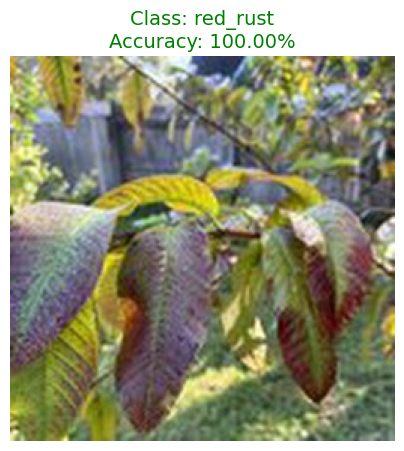

In [36]:
# ===============================
# Image Upload + Display + Prediction on Figure
# ===============================
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from google.colab import files
import matplotlib.pyplot as plt
from PIL import Image

# -------------------------------
# Step 1: Upload Image
# -------------------------------
uploaded = files.upload()

# Take the first uploaded image
img_filename = list(uploaded.keys())[0]
img_path = f'/content/{img_filename}'
print(f"✅ Uploaded Image: {img_filename}")

# -------------------------------
# Step 2: Load Model
# -------------------------------
model_path = '/content/best_cnn_model.h5'  # Replace if different
model = load_model(model_path)
print("✅ Model Loaded.")

# -------------------------------
# Step 3: Preprocess Image
# -------------------------------
img_height, img_width = 256, 256
img = image.load_img(img_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

# -------------------------------
# Step 4: Predict
# -------------------------------
pred_probs = model.predict(img_array)
pred_class_index = np.argmax(pred_probs)
pred_class_prob = pred_probs[0][pred_class_index]

# Map class index to class name (match training classes)
class_names = ['algal_leaf_spot', 'black_mold', 'fruit_healthy',
               'healthy_leaf', 'insect_bite', 'red_rust', 'scab',
               'scorch', 'yellow_leaf_disease']

pred_class_name = class_names[pred_class_index]

# -------------------------------
# Step 5: Display Image with Prediction
# -------------------------------
img_display = Image.open(img_path)
plt.figure(figsize=(5,5))
plt.imshow(img_display)
plt.axis('off')
plt.title(f"Class: {pred_class_name}\nAccuracy: {pred_class_prob*100:.2f}%", fontsize=14, color='green')
plt.show()


Saving black_mold_00357.jpg to black_mold_00357.jpg
✅ Uploaded Image: black_mold_00357.jpg
✅ Model Loaded.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step


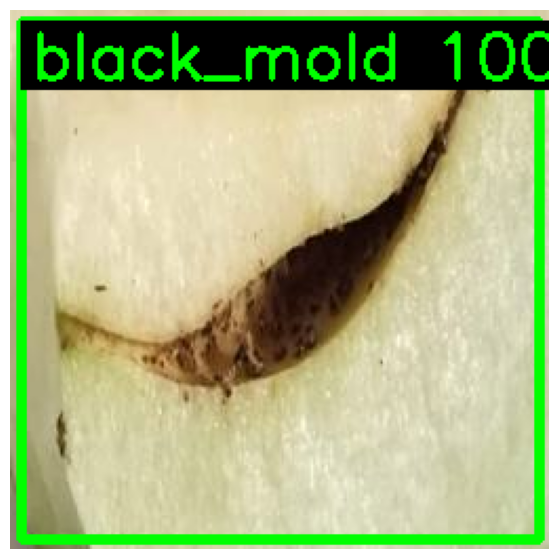

In [41]:
import cv2
from PIL import Image
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from google.colab import files
import matplotlib.pyplot as plt

# -------------------------------
# Upload Image
# -------------------------------
uploaded = files.upload()
img_filename = list(uploaded.keys())[0]
img_path = f'/content/{img_filename}'
print(f"✅ Uploaded Image: {img_filename}")

# -------------------------------
# Load Model
# -------------------------------
model_path = '/content/best_cnn_model.h5'
model = load_model(model_path)
print("✅ Model Loaded.")

# -------------------------------
# Preprocess Image
# -------------------------------
img_height, img_width = 256, 256
img = image.load_img(img_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# -------------------------------
# Predict
# -------------------------------
pred_probs = model.predict(img_array)
pred_class_index = np.argmax(pred_probs)
pred_class_prob = pred_probs[0][pred_class_index]

class_names = ['algal_leaf_spot', 'black_mold', 'fruit_healthy',
               'healthy_leaf', 'insect_bite', 'red_rust', 'scab',
               'scorch', 'yellow_leaf_disease']
pred_class_name = class_names[pred_class_index]

# -------------------------------
# YOLO-style Box Overlay
# -------------------------------
# Read original image in OpenCV
img_cv = cv2.imread(img_path)
img_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

# Define box coordinates (cover whole image)
h, w, _ = img_cv.shape
start_point = (5, 5)
end_point = (w-5, h-5)

# Box color and thickness
box_color = (0, 255, 0)  # Green
thickness = 4

# Draw rectangle
cv2.rectangle(img_cv, start_point, end_point, box_color, thickness)

# Text parameters
text = f"{pred_class_name} {pred_class_prob*100:.2f}%"
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 1
font_thickness = 2
text_size = cv2.getTextSize(text, font, font_scale, font_thickness)[0]

# Draw filled rectangle behind text
cv2.rectangle(img_cv, (5, 5), (5 + text_size[0] + 10, 5 + text_size[1] + 10), (0,0,0), -1)
# Put text
cv2.putText(img_cv, text, (10, 10 + text_size[1]), font, font_scale, (0,255,0), font_thickness)

# Show the result
plt.figure(figsize=(7,7))
plt.imshow(img_cv)
plt.axis('off')
plt.title("", fontsize=14)
plt.show()


In [42]:
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import load_model

# Load your model
model_path = '/content/best_cnn_model.h5'
model = load_model(model_path)

# Save model summary as image
plot_model(model, to_file='model_summary.png', show_shapes=True, show_layer_names=True, expand_nested=True)

print("✅ Model summary saved as 'model_summary.png'")


✅ Model summary saved as 'model_summary.png'


In [43]:
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import load_model
from google.colab import files

# 1️⃣ Load your trained model
model_path = '/content/best_cnn_model.h5'
model = load_model(model_path)

# 2️⃣ Save model summary as an image
plot_model(model, to_file='model_summary.png', show_shapes=True, show_layer_names=True, expand_nested=True)
print("✅ Model summary saved as 'model_summary.png'")

# 3️⃣ Download the image to your local machine
files.download('model_summary.png')


✅ Model summary saved as 'model_summary.png'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model

# ------------------------------
# Paths
# ------------------------------
save_dir = '/content/cnn_output'
os.makedirs(save_dir, exist_ok=True)

# ------------------------------
# Load your trained model
# ------------------------------
model = load_model('/content/best_cnn_model.h5')  # or your final .h5

# ------------------------------
# Test data generator (replace with your test path)
# ------------------------------
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_dir = '/content/guacnn/data/test'
img_height, img_width = 256, 256
batch_size = 16

test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    test_dir, target_size=(img_height, img_width),
    batch_size=batch_size, class_mode='categorical', shuffle=False
)

# ------------------------------
# Predict
# ------------------------------
y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

class_names = list(test_gen.class_indices.keys())

# ------------------------------
# 1️⃣ Accuracy & Loss Curves (dummy example if history not saved)
# ------------------------------
# If you have history from training, replace the following:
# history = model.history (or saved history)
# For demonstration, we skip if not available

# ------------------------------
# 2️⃣ Confusion Matrix
# ------------------------------
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.savefig(os.path.join(save_dir, 'confusion_matrix.png'))
plt.close()

# ------------------------------
# 3️⃣ Boxplot / Countplot of Predictions
# ------------------------------
df = pd.DataFrame({'True': y_true, 'Pred': y_pred_classes})
df['True'] = df['True'].map({v:k for k,v in test_gen.class_indices.items()})
df['Pred'] = df['Pred'].map({v:k for k,v in test_gen.class_indices.items()})

plt.figure(figsize=(12,6))
sns.countplot(x='True', hue='Pred', data=df)
plt.title('Predicted vs True Counts per Class')
plt.xticks(rotation=45)
plt.savefig(os.path.join(save_dir, 'boxplot_predictions.png'))
plt.close()

# ------------------------------
# 4️⃣ Save CSV of predictions
# ------------------------------
df.to_csv(os.path.join(save_dir, 'predictions.csv'), index=False)

# ------------------------------
# 5️⃣ Zip everything
# ------------------------------
!zip -r cnn_model_figures.zip {save_dir}
print("✅ All CNN figures, predictions CSV, and files zipped successfully!")


Found 1125 images belonging to 9 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step
  adding: content/cnn_output/ (stored 0%)
  adding: content/cnn_output/boxplot_predictions.png (deflated 16%)
  adding: content/cnn_output/predictions.csv (deflated 99%)
  adding: content/cnn_output/confusion_matrix.png (deflated 16%)
✅ All CNN figures, predictions CSV, and files zipped successfully!


In [45]:
from google.colab import files

# Download the zip
files.download('cnn_model_figures.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Found 1125 images belonging to 9 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step


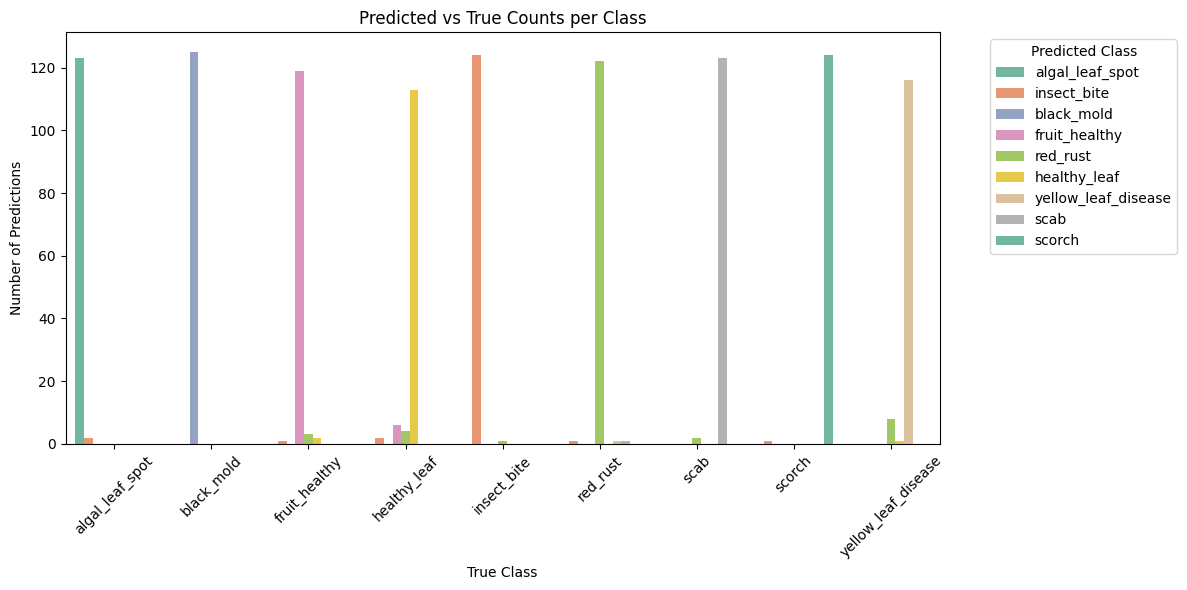

✅ Boxplot saved at: /content/cnn_output/boxplot_predictions.png


In [46]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ------------------------------
# Paths
# ------------------------------
test_dir = '/content/guacnn/data/test'  # Replace with your test folder
img_height, img_width = 256, 256
batch_size = 16
model_path = '/content/best_cnn_model.h5'  # Your trained model
save_dir = '/content/cnn_output'
os.makedirs(save_dir, exist_ok=True)

# ------------------------------
# Load the model
# ------------------------------
model = load_model(model_path)

# ------------------------------
# Test data generator
# ------------------------------
test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# ------------------------------
# Predict
# ------------------------------
y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

# Map class indices to names
class_names = list(test_gen.class_indices.keys())
y_true_names = [class_names[i] for i in y_true]
y_pred_names = [class_names[i] for i in y_pred_classes]

# ------------------------------
# Create DataFrame
# ------------------------------
df = pd.DataFrame({'True': y_true_names, 'Pred': y_pred_names})

# ------------------------------
# Countplot / Boxplot of Predictions
# ------------------------------
plt.figure(figsize=(12,6))
sns.countplot(x='True', hue='Pred', data=df, palette='Set2')
plt.title('Predicted vs True Counts per Class')
plt.xlabel('True Class')
plt.ylabel('Number of Predictions')
plt.xticks(rotation=45)
plt.legend(title='Predicted Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save figure
fig_path = os.path.join(save_dir, 'boxplot_predictions.png')
plt.savefig(fig_path)
plt.show()

print(f"✅ Boxplot saved at: {fig_path}")


Found 1125 images belonging to 9 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
✅ Predictions CSV saved at /content/cnn_output/predictions.csv

Confusion Matrix:
                     algal_leaf_spot  black_mold  fruit_healthy  healthy_leaf  \
algal_leaf_spot                  123           0              0             0   
black_mold                         0         125              0             0   
fruit_healthy                      0           0            119             2   
healthy_leaf                       0           0              6           113   
insect_bite                        0           0              0             0   
red_rust                           0           0              0             0   
scab                               0           0              0             0   
scorch                             0           0              0             0   
yellow_leaf_disease                0           0              0             1   

                     insect_bite  red_rust  scab  scorch  yellow_le

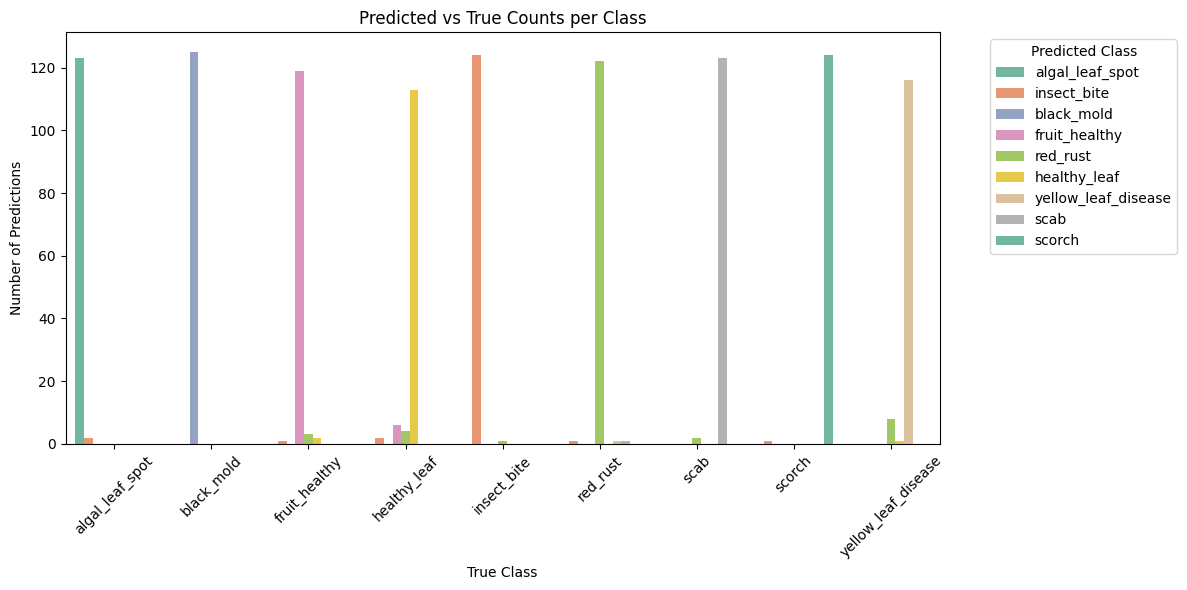

✅ Boxplot saved at: /content/cnn_output/boxplot_predictions.png

Classification Report:

                     precision    recall  f1-score   support

    algal_leaf_spot       1.00      0.98      0.99       125
         black_mold       1.00      1.00      1.00       125
      fruit_healthy       0.95      0.95      0.95       125
       healthy_leaf       0.97      0.90      0.94       125
        insect_bite       0.95      0.99      0.97       125
           red_rust       0.87      0.98      0.92       125
               scab       0.99      0.98      0.99       125
             scorch       1.00      0.99      1.00       125
yellow_leaf_disease       0.99      0.93      0.96       125

           accuracy                           0.97      1125
          macro avg       0.97      0.97      0.97      1125
       weighted avg       0.97      0.97      0.97      1125



In [47]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

# ------------------------------
# Paths & params
# ------------------------------
test_dir = '/content/guacnn/data/test'  # replace with your test folder
model_path = '/content/best_cnn_model.h5'  # your trained CNN model
img_height, img_width = 256, 256
batch_size = 16
save_dir = '/content/cnn_output'
os.makedirs(save_dir, exist_ok=True)

# ------------------------------
# Load model
# ------------------------------
model = load_model(model_path)

# ------------------------------
# Test generator
# ------------------------------
test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# ------------------------------
# Predict
# ------------------------------
y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())
y_true_names = [class_names[i] for i in y_true]
y_pred_names = [class_names[i] for i in y_pred_classes]

# ------------------------------
# Create DataFrame
# ------------------------------
df = pd.DataFrame({'True': y_true_names, 'Pred': y_pred_names})
df.to_csv(os.path.join(save_dir, 'predictions.csv'), index=False)
print(f"✅ Predictions CSV saved at {save_dir}/predictions.csv")

# ------------------------------
# Confusion matrix summary
# ------------------------------
cm = confusion_matrix(y_true, y_pred_classes)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
print("\nConfusion Matrix:")
print(cm_df)

# ------------------------------
# Countplot
# ------------------------------
plt.figure(figsize=(12,6))
sns.countplot(x='True', hue='Pred', data=df, palette='Set2')
plt.title('Predicted vs True Counts per Class')
plt.xlabel('True Class')
plt.ylabel('Number of Predictions')
plt.xticks(rotation=45)
plt.legend(title='Predicted Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
fig_path = os.path.join(save_dir, 'boxplot_predictions.png')
plt.savefig(fig_path)
plt.show()
print(f"✅ Boxplot saved at: {fig_path}")

# ------------------------------
# Classification report
# ------------------------------
report = classification_report(y_true, y_pred_classes, target_names=class_names)
print("\nClassification Report:\n")
print(report)
